In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

In [2]:
dataset_path = r"D:\dataset\raw_data"
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1376 images belonging to 2 classes.
Found 344 images belonging to 2 classes.
Found 430 images belonging to 2 classes.


In [5]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
base_model.trainable = False

In [7]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8
)

Epoch 1/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.7464 - loss: 0.5072 - val_accuracy: 0.9390 - val_loss: 0.1959
Epoch 2/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9106 - loss: 0.2283 - val_accuracy: 0.9622 - val_loss: 0.1260
Epoch 3/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9411 - loss: 0.1695 - val_accuracy: 0.9535 - val_loss: 0.1170
Epoch 4/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9455 - loss: 0.1428 - val_accuracy: 0.9622 - val_loss: 0.0938
Epoch 5/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9549 - loss: 0.1296 - val_accuracy: 0.9564 - val_loss: 0.0918
Epoch 6/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9695 - loss: 0.0993 - val_accuracy: 0.9622 - val_loss: 0.0863
Epoch 7/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9753 - loss: 0.0871 - val_accuracy: 0.9622 - val_loss: 0.0839
Epoch 8/8
43/43 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9789 - loss: 0.0796 - val_accuracy: 0.9651 - val_loss:

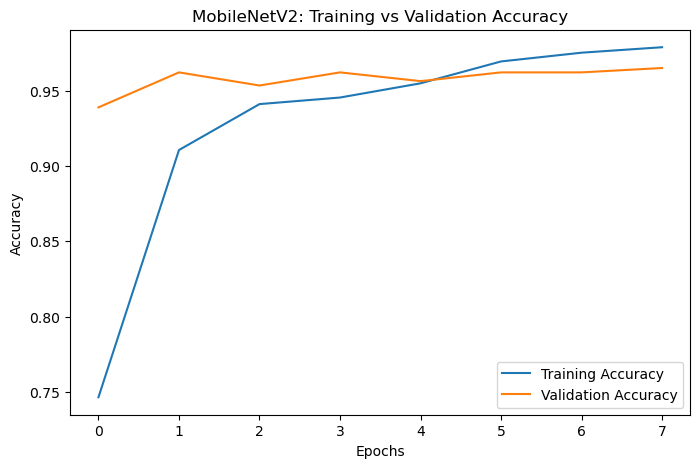

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

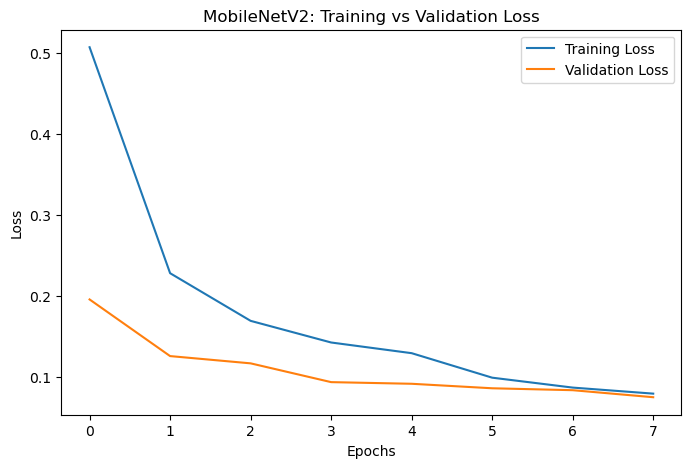

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print("MobileNetV2 Test Loss:", test_loss)
print("MobileNetV2 Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.8977 - loss: 0.2337
MobileNetV2 Test Loss: 0.23372268676757812
MobileNetV2 Test Accuracy: 0.8976744413375854


## Observation: Transfer Learning with MobileNetV2
A pretrained MobileNetV2 model is used as a feature extractor for binary classification of ocean images.
Transfer learning is expected to improve generalization because the base model has already learned strong visual features from ImageNet.
This model is compared with the baseline CNN to analyze performance improvement.

## Model Comparison

| Model | Best Validation Accuracy | Test Accuracy | Remarks |
|---|---:|---:|---|
| Baseline CNN | 90.12% | 76.05% | Overfitting observed |
| MobileNetV2 | 96.51% | 89.77% | Better feature extraction and generalization |

## Conclusion
This project successfully developed two deep learning models for marine plastic waste detection from ocean images.

The baseline CNN achieved strong training performance but showed overfitting, resulting in a lower test accuracy of 76.05%.

To improve generalization, transfer learning with MobileNetV2 was implemented.
The MobileNetV2 model significantly outperformed the baseline CNN, achieving 89.77% test accuracy and better validation stability.

These results demonstrate that transfer learning is highly effective for environmental image classification tasks and can support marine pollution monitoring systems.

In [16]:
model.save("mobilenet_oceanplastic_detector.keras")

In [17]:
from tensorflow.keras.models import load_model

model = load_model("mobilenet_oceanplastic_detector.keras")

C:\Users\RAGA AMIRTHA\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
